In [3]:
# Importing Necessary Libraries
import cv2
import os
import shutil
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")
import zipfile
# Extract the ZIP file
with zipfile.ZipFile('/content/navindra.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
# Update the data_dir to the extracted folder
data_dir = '/content/extracted_folder'

In [4]:
import os
import zipfile
import cv2
import numpy as np
import math
from sklearn.metrics import mean_squared_error
from datetime import datetime
import shutil

def findDelDuplImg(file_name, file_dir):
    searchedImgPath = os.path.join(file_dir, file_name)
    searchedImage = np.array(cv2.imread(searchedImgPath, 0))
    # Start iterate over all images
    for cmpImageName in os.listdir(file_dir):
        if cmpImageName != file_name:
            # If name is different
            try:
                # Concatenate path to image
                cmpImagePath = os.path.join(file_dir, cmpImageName)
                # Open image to be compared
                cmpImage = np.array(cv2.imread(cmpImagePath, 0))
                # Count root mean square between both images (RMS)
                rms = math.sqrt(mean_squared_error(searchedImage, cmpImage))
            except:
                continue
            # If RMS is smaller than 3 - this means that images are similar or the same
            if rms < 3:
                # Delete Same Image in Dir
                os.remove(cmpImagePath)

def processDataset(zip_path, dataset_dest):
    # Create a temporary directory for extraction
    extracted_path = '/content/temp_extraction'
    os.makedirs(extracted_path, exist_ok=True)

    try:
        # Extract the ZIP file
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extracted_path)

        # Check if there's an extra directory level
        subdirs = [d for d in os.listdir(extracted_path) if os.path.isdir(os.path.join(extracted_path, d))]
        if len(subdirs) == 1:
            # If there's only one directory within extracted_path, use it as the dataset
            extracted_path = os.path.join(extracted_path, subdirs[0])

        # Generate a unique destination directory using a timestamp
        timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
        dataset_dest = os.path.join(dataset_dest, f'OralCancer_{timestamp}')

        # Making a Copy of Dataset
        os.makedirs(dataset_dest, exist_ok=True)

        for folder in os.listdir(extracted_path):
            for (index, file) in enumerate(os.listdir(os.path.join(extracted_path, folder)), start=1):
                filename = f'img_{folder}_{index}.jpg'
                img_src = os.path.join(extracted_path, folder, file)
                img_des = os.path.join(dataset_dest, filename)
                # Preprocess the Images
                img = cv2.imread(img_src)
                img = cv2.resize(img, (256, 256))
                img = cv2.copyMakeBorder(img, 2, 2, 2, 2, cv2.BORDER_CONSTANT, value=0)
                img = cv2.blur(img, (2, 2))
                cv2.imwrite(img_des, img)

            for file in os.listdir(os.path.join(extracted_path, folder)):
                # Find duplicated images and delete duplicates.
                findDelDuplImg(file, os.path.join(extracted_path, folder))

    except Exception as e:
        print(f"Error: {e}")

    finally:
        # Remove the temporary extraction directory
        shutil.rmtree(extracted_path)

# Source Location for ZIP Dataset
zip_path = '/content/navindra.zip'
# Destination Location for Dataset
dataset_dest = '/content'

# Image preprocessing
processDataset(zip_path, dataset_dest)


In [5]:
def GetDatasetSize(path):
    num_of_image = {}
    for folder in os.listdir(path):
        # Counting the Number of Files in the Folder
        num_of_image[folder] = len(os.listdir(os.path.join(path, folder)));
    return num_of_image;

path = "./OralCancer"
DatasetSize = GetDatasetSize(path);
print(DatasetSize);

{'non-cancer': 144, 'cancer': 216}


In [6]:
def TrainValTestSplit(root_dir, classes_dir, val_ratio = 0.15, test_ratio = 0.15):
    for cls in classes_dir:
        # Creating Split Folders
        os.makedirs('train/' + cls)
        os.makedirs('val/' + cls)
        os.makedirs('test/' + cls)

        # Folder to copy images from
        src = root_dir + cls

        # Storing the Filenames
        allFileNames = os.listdir(src)
        np.random.shuffle(allFileNames)
        # Spliting the Files in the Given ratio
        train_FileNames, val_FileNames, test_FileNames = np.split(np.array(allFileNames), [int(len(allFileNames)* (1 - (val_ratio + test_ratio))), int(len(allFileNames)* (1 - test_ratio))])

        train_FileNames = [src+'/'+ name for name in train_FileNames.tolist()]
        val_FileNames = [src+'/' + name for name in val_FileNames.tolist()]
        test_FileNames = [src+'/' + name for name in test_FileNames.tolist()]

        # Printing the Split Details
        print(cls.upper(),':')
        print('Total images: ', len(allFileNames))
        print('Training: ', len(train_FileNames))
        print('Validation: ', len(val_FileNames))
        print('Testing: ', len(test_FileNames))

        # Copy-pasting images
        for name in train_FileNames:
            shutil.copy(name, 'train/' + cls)

        for name in val_FileNames:
            shutil.copy(name, 'val/' + cls)

        for name in test_FileNames:
            shutil.copy(name, 'test/' + cls)
        print();

# Preforming Train / Validation / Test Split
root_dir = './OralCancer/'              # Dataset Root Folder
classes_dir = ['cancer', 'non-cancer']  # Classes
TrainValTestSplit(root_dir, classes_dir);

CANCER :
Total images:  216
Training:  151
Validation:  32
Testing:  33

NON-CANCER :
Total images:  144
Training:  100
Validation:  22
Testing:  22



In [7]:
import keras
from keras.layers import Dense,Conv2D, Flatten, MaxPool2D, Dropout
from keras.models import Sequential
from keras.preprocessing import image
from keras.callbacks import ModelCheckpoint
from keras.models import load_model

In [8]:

model = Sequential()

# Convolutional Layer with input shape (256,256,3)
model.add(Conv2D(filters=32, kernel_size= (3,3), activation= 'relu', input_shape=(256,256,3)) )

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu' ))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu' ))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu' ))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Dropout(rate=0.25))

model.add(Flatten())
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(rate=0.25))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']  )

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 252, 252, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 126, 126, 32)      0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 124, 124, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 60, 60, 128)       7

In [9]:
# Expand the size of dataset with new transformed images from the original dataset using ImageDataGenerator.
train_datagen = image.ImageDataGenerator(zoom_range = 0.2, shear_range = 0.2 , rescale = 1./255 , horizontal_flip=True)
val_datagen = image.ImageDataGenerator(rescale = 1./255)
test_datagen = image.ImageDataGenerator(rescale = 1./255)

In [10]:
train_data = train_datagen.flow_from_directory(directory= "./train", target_size=(256,256), batch_size=32, class_mode = 'binary')

Found 251 images belonging to 2 classes.


In [11]:
train_data.class_indices

{'cancer': 0, 'non-cancer': 1}

In [12]:
val_data = val_datagen.flow_from_directory(directory= "./val", target_size=(256,256), batch_size=32, class_mode = 'binary')

Found 54 images belonging to 2 classes.


In [13]:
test_data = test_datagen.flow_from_directory(directory= "./test", target_size=(256,256), batch_size=32, class_mode = 'binary')

Found 55 images belonging to 2 classes.


In [14]:
mc = ModelCheckpoint(filepath="oral_cancer_best_model.hdf5", monitor= 'val_accuracy', verbose= 1, save_best_only= True, mode = 'auto');
call_back = [ mc ];

In [ ]:
cnn = model.fit(train_data,
                  steps_per_epoch = 2,
                  epochs = 32,
                  validation_data = val_data,
                  validation_steps = 1,
                  callbacks = call_back )

Epoch 1/32
2/2 [==============================] - ETA: 0s - loss: 1.0283 - accuracy: 0.6875 
Epoch 1: val_accuracy improved from -inf to 0.37500, saving model to oral_cancer_best_model.hdf5
2/2 [==============================] - 28s 11s/step - loss: 1.0283 - accuracy: 0.6875 - val_loss: 1.6893 - val_accuracy: 0.3750
Epoch 2/32
2/2 [==============================] - ETA: 0s - loss: 1.1922 - accuracy: 0.4531
Epoch 2: val_accuracy improved from 0.37500 to 0.53125, saving model to oral_cancer_best_model.hdf5
2/2 [==============================] - 19s 10s/step - loss: 1.1922 - accuracy: 0.4531 - val_loss: 0.6901 - val_accuracy: 0.5312
Epoch 3/32
2/2 [==============================] - ETA: 0s - loss: 0.6722 - accuracy: 0.5781
Epoch 3: val_accuracy did not improve from 0.53125
2/2 [==============================] - 20s 11s/step - loss: 0.6722 - accuracy: 0.5781 - val_loss: 0.7925 - val_accuracy: 0.4375
Epoch 4/32
2/2 [==============================] - ETA: 0s - loss: 0.6934 - accuracy: 0.5593

In [ ]:
# Loading the Best Fit Model
model = load_model("./oral_cancer_best_model.hdf5")

In [ ]:
# Checking the Accuracy of the Model
accuracy = model.evaluate_generator(generator= test_data)[1]
print(f"The accuracy of the model is = {accuracy*100} %")

The accuracy of the model is = 60.00000238418579 %


In [ ]:
h =  cnn.history
h.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

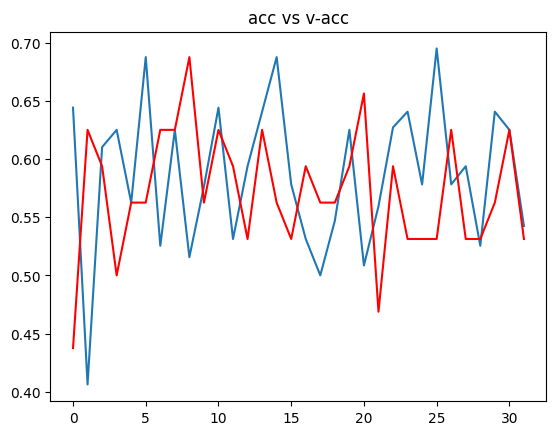

In [ ]:
# Ploting Accuracy In Training Set & Validation Set
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'] , c = "red")
plt.title("acc vs v-acc")
plt.show()

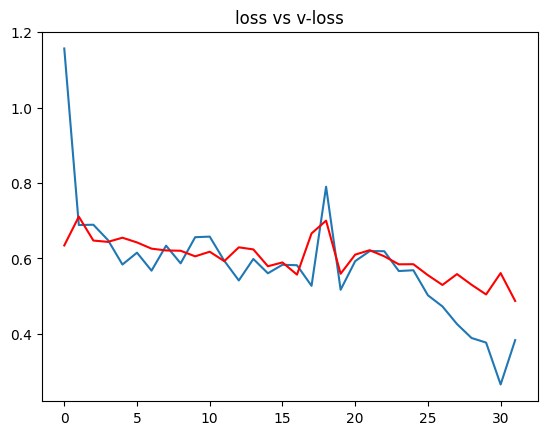

In [ ]:
# Ploting Loss In Training Set & Validation Set
plt.plot(h['loss'])
plt.plot(h['val_loss'] , c = "red")
plt.title("loss vs v-loss")
plt.show()

In [ ]:

def cancerPrediction(path):
    # Loading Image
    img = image.load_img(path, target_size=(256,256))
    # Normalizing Image
    norm_img = image.img_to_array(img)/255
    # Converting Image to Numpy Array
    input_arr_img = np.array([norm_img])
    # Getting Predictions
    pred = (model.predict(input_arr_img) > 0.5).astype(int)[0][0]
    # Printing Model Prediction
    if pred == 0:
        print("Cancer")
    else:
        print("Non-Cancer")

# Path for the image to get predictions
path = "/content/can.jpg"
cancerPrediction(path)

1/1 [==============================] - 1s 725ms/step
Cancer
